**Exploratory Data Analysis and Hypothesis Testing**

In this notebook I will clean the data and conduct exploratory data analysis. Recall that:

1. Null Hypothesis: The mean of the lifespan (duration on trends) of the memes that are emerged before 2020 (The year Instagram Reels and Youtube Shorts Released) is the same as those of that emerged after 2020
2. Alternative Hypothesis: The mean of the the lifespan of memes that are emerged before 2020 is longer than those of the memes emerged after 2020

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

#Read the csv file 
df_main=pd.read_csv("/Users/batuhanozkaya/Desktop/Sophomore/Fall 2025/DSA 210/Term Project/Company-Policies-And-Meme-Inflation/Exploratory_Data_Analysis/meme_lifespan_data_raw_copy.csv")
df_main.head()

,Unnamed: 0,origin_year,origin_platform,weeks_of_trends
0,pedobear,2003,4chan,201.0
1,tinaecmusic,2007,YouTube,7.0
2,raptor jesus,2005,4chan,233.0
3,when you see it,2008,NaN,210.0
4,charlie bit my finger,2007,YouTube,160.0


In [8]:
print(df_main.info())
print("***************")
print("Shape of the DataFrame:",df_main.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1784 entries, 0 to 1783
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       1784 non-null   object 
 1   origin_year      1784 non-null   int64  
 2   origin_platform  691 non-null    object 
 3   weeks_of_trends  1779 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 55.9+ KB
None
***************
Shape of the DataFrame: (1784, 4)


We can see that all memes have a origin_year.
 Not all of them has origin_platform;however, it makes sense since some of them emerged from movies etc., but there is two problems with weeks_of_trends feature:
1. There are some memes that are considered to be on trends for 0 weeks. That is because the memes that were originated before 2000s or at the beginning 2000s became trend much later on; therefore, real interest is missed. Additionaly, especially memes in post-2020 era are registered on the website with very long names making the trend search irrelevant (e.g. "donald trumps hand makeup and death speculation" meme on KYM.com does not have any Google Trend data, but interest in "donald trump death meme" was on trends for nearly 8 weeks)
2. Some of the memes were on trends of 235 weeks which is the maximum time frame used when fetching data from Google Trends. These memes usually are the ones that are not only memes but also general public interests. For instance, "Taylor Swift" and "Drake" memes appear on trend for 235 weeks in our csv dataset.

The columns having these two properties will be eliminated in order to get more accurate results.

In [19]:
print("Maximum value of weeks_of_trends:",df_main["weeks_of_trends"].max())
print("Minimum value of weeks_of_trends:",df_main["weeks_of_trends"].min())

df_clean=df_main[~((df_main["weeks_of_trends"] == 0) | (df_main["weeks_of_trends"] == 235))]
df_clean=df_clean.rename(columns={'Unnamed: 0':'name'})
df_clean=df_clean.dropna(subset=["weeks_of_trends"])
print(df_clean.info())
print("***************")
print("Shape of the DataFrame:",df_clean.shape)

Maximum value of weeks_of_trends: 235.0
Minimum value of weeks_of_trends: 0.0
<class 'pandas.core.frame.DataFrame'>
Index: 1263 entries, 0 to 1783
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1263 non-null   object 
 1   origin_year      1263 non-null   int64  
 2   origin_platform  498 non-null    object 
 3   weeks_of_trends  1263 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 49.3+ KB
None
***************
Shape of the DataFrame: (1263, 4)


In [20]:
#Split the data pre-2020 and post-2020
df_post2020=df_clean[df_clean['origin_year']>=2020]
df_pre2020=df_clean[df_clean['origin_year']<2020]

print(df_pre2020.info())
print("***************")
print(df_post2020.info())

<class 'pandas.core.frame.DataFrame'>
Index: 865 entries, 0 to 1779
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             865 non-null    object 
 1   origin_year      865 non-null    int64  
 2   origin_platform  355 non-null    object 
 3   weeks_of_trends  865 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 33.8+ KB
None
***************
<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 945 to 1783
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             398 non-null    object 
 1   origin_year      398 non-null    int64  
 2   origin_platform  143 non-null    object 
 3   weeks_of_trends  398 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 15.5+ KB
None


As now the datasets are clean and seperated, basic data analysis of group properties can be conducted

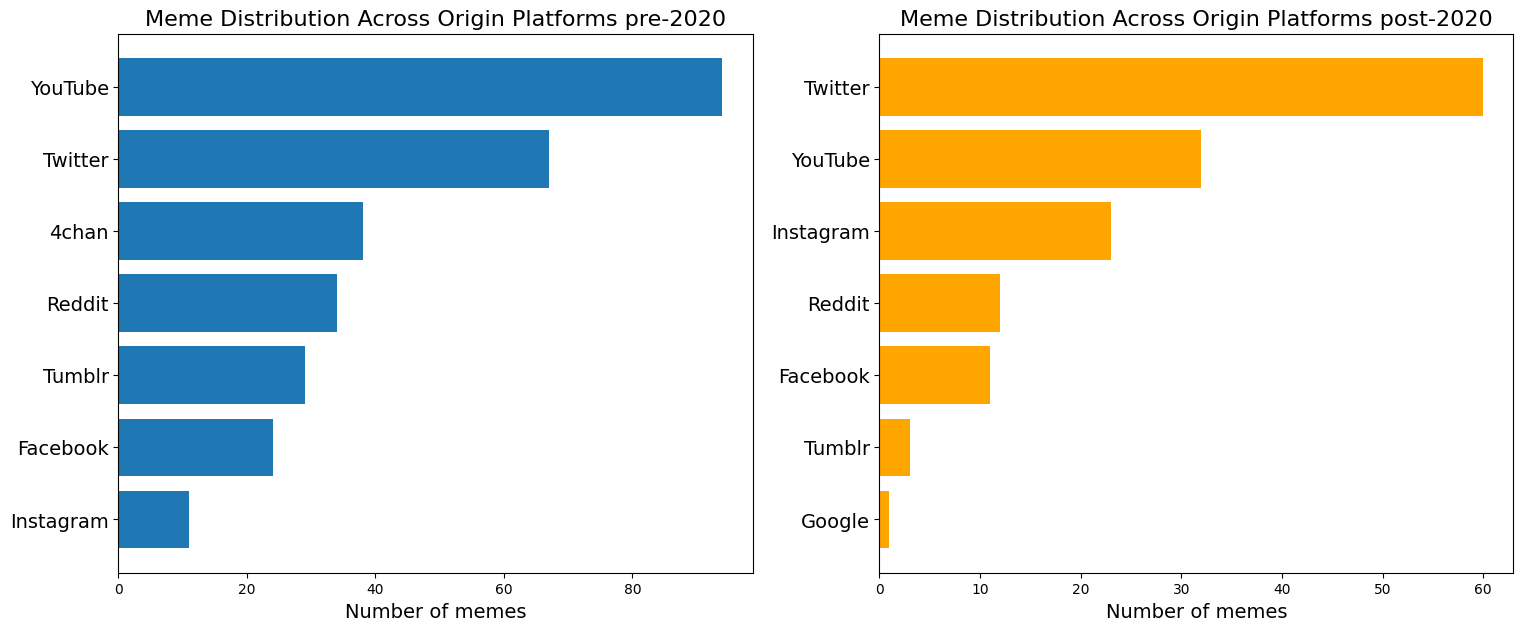

In [44]:
#Check the distrubiton of memes accross platfroms
figs,axs=plt.subplots(1,2,figsize=(18,7))

axs[0].barh(df_pre2020['origin_platform'].value_counts().index[:7],df_pre2020['origin_platform'].value_counts().values[:7])
axs[0].set_title("Meme Distribution Across Origin Platforms pre-2020",fontsize=16)
axs[0].set_xlabel("Number of memes",fontsize=14)
axs[0].invert_yaxis()
axs[0].tick_params(axis="y",labelsize=14)

axs[1].barh(df_post2020['origin_platform'].value_counts().index[:7],df_post2020['origin_platform'].value_counts().values[:7],color='orange')
axs[1].set_title("Meme Distribution Across Origin Platforms post-2020",fontsize=16)
axs[1].set_xlabel("Number of memes",fontsize=14)
axs[1].invert_yaxis()
axs[1].tick_params(axis="y",labelsize=14)

plt.show()


Above graphs clearly indicate that there is a drastic change in platforms where new memes emerge. After 2020, platforms such as 4chan are dissappeared from the list of top platforms, while Twitter/X replaces YouTube as the most popular platform new memes emerge

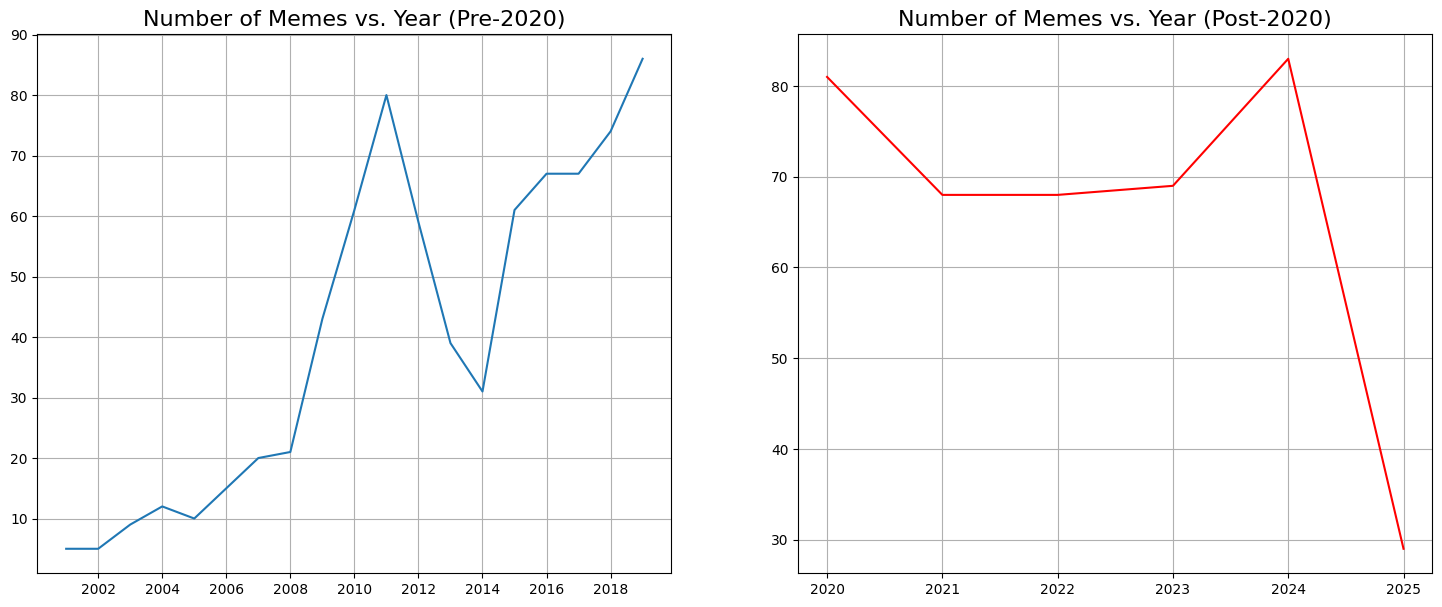

In [81]:
#Check the number of memes accross years
from matplotlib.ticker import MaxNLocator

figs,axs=plt.subplots(1,2,figsize=(18,7))
#memes that have origin_year later than 2000 is considered since some memes can date back 17th century and some memes has the origin_year value of zero since it is unknown
axs[0].plot(df_pre2020[df_pre2020['origin_year']>2000]['origin_year'].value_counts().sort_index().index,
            df_pre2020[df_pre2020['origin_year']>2000]['origin_year'].value_counts().sort_index().values)
axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[0].grid(True)
axs[0].set_title("Number of Memes vs. Year (Pre-2020)",fontsize=16)

axs[1].plot(df_post2020[df_post2020['origin_year']>2000]['origin_year'].value_counts().sort_index().index,
            df_post2020[df_post2020['origin_year']>2000]['origin_year'].value_counts().sort_index().values,color="red")
axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1].grid(True)
axs[1].set_title("Number of Memes vs. Year (Post-2020)",fontsize=16)
plt.show()



The problem with 2025 is that long and irrelevant meme names on KnowYourMeme.com results in no data when pytrend search is done because the people have different ways to search this meme. The example was given in the data cleaning section. Highest number of memes occur in 2019-2020 which is expected due to the Covid lockdown

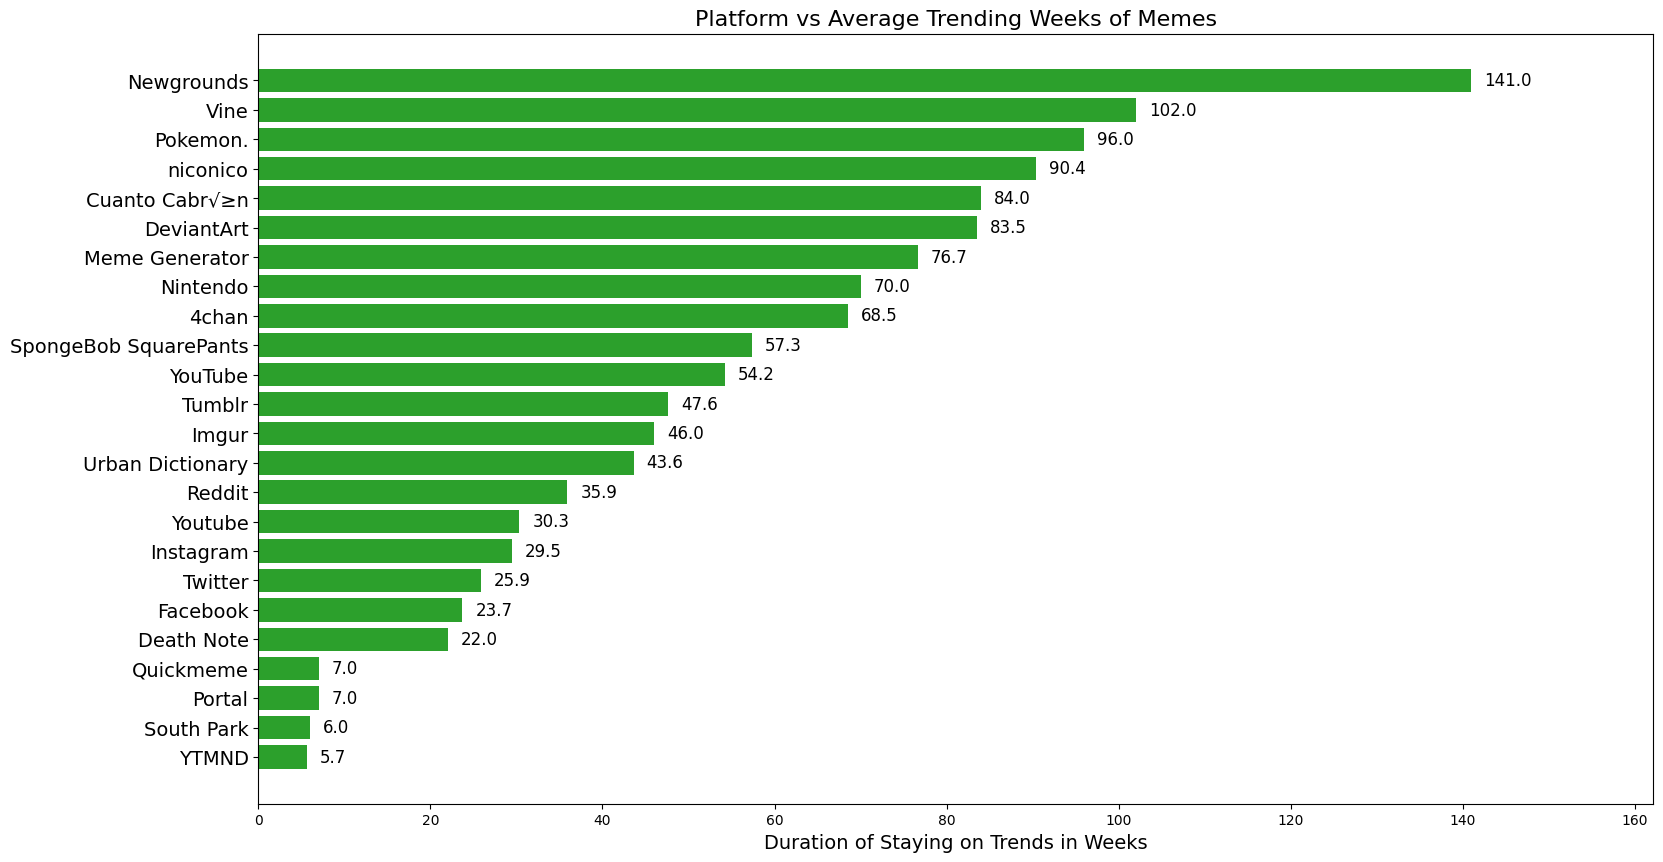

In [116]:
#Analyze the relation between staying on trends and origin platform

platform_avg=df_clean.groupby('origin_platform')['weeks_of_trends'].mean()
platform_avg = platform_avg.sort_values(ascending=False)

fig,ax=plt.subplots(figsize=(18,10))

ax.barh(platform_avg.index[:24],platform_avg.values[:24],color='#2ca02c')
ax.invert_yaxis()

ax.set_xlabel("Duration of Staying on Trends in Weeks", fontsize=14)
ax.set_title("Platform vs Average Trending Weeks of Memes",fontsize=16)

ax.tick_params(axis="y",labelsize=14)

for i, v in enumerate(platform_avg.values[:24]):
    ax.text(v + 1.5, i, f'{v:.1f}', 
            color='black', 
            va='center',     
            ha='left',        
            fontsize=12)

max_val = platform_avg.max()
ax.set_xlim(right=max_val * 1.15)
            
plt.show()

Graph above is clear;however, it is important to remember that if there is a platfrom where single meme having a very long duration, then its average also becomes very high regardless of performance of other memes from the same platfrom if they exist

***Hypothesis Testing***

Until now, general data and group properties were analyzed. Part below will examine the relation between average lifespan of memes from pre-2020 and post-2020 in order to test the hyptohesis. Since I am comparing means, and distributions are not normal, the best approach would be Mann-Whitney U-Test.

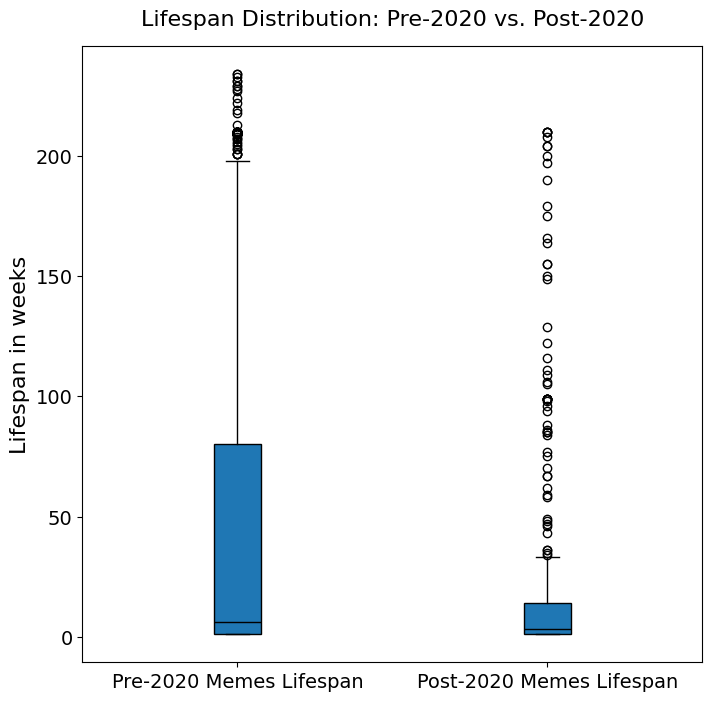

In [115]:
fig,ax=plt.subplots(figsize=(8,8))

ax.boxplot(
    [pre2020_list,post2020_list],
    vert=True,
    patch_artist=True,
    tick_labels=["Pre-2020 Memes Lifespan","Post-2020 Memes Lifespan"],
    medianprops=dict(color='black')
)

ax.set_title('Lifespan Distribution: Pre-2020 vs. Post-2020', fontsize=16, pad=15)
ax.set_ylabel("Lifespan in weeks",fontsize=16)
ax.tick_params(axis="x",labelsize=14)
ax.tick_params(axis="y",labelsize=14)

plt.show()

Above Box Plot demonstrates that the medians of the two group is similar;nevertheless, there is a great difference between how two groups distribute. Now that we have general insights about lifespan parameters of pre- and post-2020 memes, we can proceed with Mann-Whitney U Test.

In [90]:
from scipy import stats

#Convert the weeks_of_trends columns of dataframes to list so that they can be compared in mannwhitneyu function 
pre2020_list=df_pre2020["weeks_of_trends"].to_list()
post2020_list=df_post2020["weeks_of_trends"].to_list()


u_statistic,p_value=stats.mannwhitneyu(
    pre2020_list,
    post2020_list,
    alternative='greater' #Since we want to check whether pre2020_list having a longer lifespan or not.
)

print(f"P-value of the test: {p_value:.10f}")

P-value of the test: 0.0000001116


***Since p-value of the test is much smaller than the chosen significance value (0.0000001<0.05) we can reject the null hypothesis. Even though the medians are similar in these two groups there is a drastic change in overall lifespan distribution of memes emerged before and after 2020***